In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [3]:
import os

# Check your Smart-SOC folder
path = '/content/drive/MyDrive/Smart-SOC/cicids2017'
files = os.listdir(path)
print("✅ Files found:")
for f in files:
    size = os.path.getsize(f'{path}/{f}') / (1024*1024)
    print(f"  {f} → {size:.1f} MB")

✅ Files found:
  friday.csv → 190.7 MB
  friday_plus.csv → 232.9 MB
  monday.csv → 139.4 MB
  monday_plus.csv → 166.4 MB
  thursday.csv → 126.4 MB
  thursday_plus.csv → 153.6 MB
  tuesday.csv → 119.6 MB
  tuesday_plus.csv → 142.4 MB
  wednesday.csv → 197.4 MB
  wednesday_plus.csv → 235.0 MB


In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

path = '/content/drive/MyDrive/Smart-SOC/cicids2017'

print("📂 Loading all files...")
dfs = []
for f in sorted(os.listdir(path)):
    if f.endswith('.csv'):
        df = pd.read_csv(f'{path}/{f}', low_memory=False)
        print(f"  ✅ {f} → {df.shape}")
        dfs.append(df)

# Combine all
full_df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined dataset shape: {full_df.shape}")
print(f"✅ Total records: {full_df.shape[0]:,}")

📂 Loading all files...
  ✅ friday.csv → (547557, 89)
  ✅ friday_plus.csv → (547557, 105)
  ✅ monday.csv → (371621, 89)
  ✅ monday_plus.csv → (371621, 105)
  ✅ thursday.csv → (362075, 89)
  ✅ thursday_plus.csv → (362075, 105)
  ✅ tuesday.csv → (322078, 89)
  ✅ tuesday_plus.csv → (322078, 105)
  ✅ wednesday.csv → (496640, 89)
  ✅ wednesday_plus.csv → (496640, 105)

✅ Combined dataset shape: (4199942, 105)
✅ Total records: 4,199,942


In [5]:
# Check column difference
df_normal = pd.read_csv(f'{path}/friday.csv', low_memory=False, nrows=1)
df_plus = pd.read_csv(f'{path}/friday_plus.csv', low_memory=False, nrows=1)

print(f"Normal files columns: {len(df_normal.columns)}")
print(f"Plus files columns:   {len(df_plus.columns)}")

# Find extra columns in plus files
extra_cols = set(df_plus.columns) - set(df_normal.columns)
print(f"\nExtra columns in plus files:")
for c in sorted(extra_cols):
    print(f"  {c}")

# Find label column
print(f"\nLabel column in normal: {[c for c in df_normal.columns if 'label' in c.lower()]}")
print(f"Label column in plus:   {[c for c in df_plus.columns if 'label' in c.lower()]}")

Normal files columns: 89
Plus files columns:   105

Extra columns in plus files:
  Flow ID
  Local
  Local_1
  Local_10
  Local_11
  Local_12
  Local_13
  Local_14
  Local_2
  Local_3
  Local_4
  Local_5
  Local_6
  Local_7
  Local_8
  Local_9

Label column in normal: ['Label']
Label column in plus:   ['Label']


In [6]:
# Get common columns from normal files
common_cols = list(df_normal.columns)
print(f"✅ Using {len(common_cols)} common columns")

# Reload all files with only common columns
print("\n📂 Reloading all files with common columns...")
dfs = []
for f in sorted(os.listdir(path)):
    if f.endswith('.csv'):
        df = pd.read_csv(f'{path}/{f}', low_memory=False, usecols=common_cols)
        dfs.append(df)
        print(f"  ✅ {f} → {df.shape}")

# Combine
full_df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined shape: {full_df.shape}")
print(f"✅ Total records:  {full_df.shape[0]:,}")
print(f"✅ Total columns:  {full_df.shape[1]}")

✅ Using 89 common columns

📂 Reloading all files with common columns...
  ✅ friday.csv → (547557, 89)
  ✅ friday_plus.csv → (547557, 89)
  ✅ monday.csv → (371621, 89)
  ✅ monday_plus.csv → (371621, 89)
  ✅ thursday.csv → (362075, 89)
  ✅ thursday_plus.csv → (362075, 89)
  ✅ tuesday.csv → (322078, 89)
  ✅ tuesday_plus.csv → (322078, 89)
  ✅ wednesday.csv → (496640, 89)
  ✅ wednesday_plus.csv → (496640, 89)

✅ Combined shape: (4199942, 89)
✅ Total records:  4,199,942
✅ Total columns:  89


In [7]:
# Check attack types
print("=== Attack Type Distribution ===")
print(full_df['Label'].value_counts())
print(f"\nTotal unique labels: {full_df['Label'].nunique()}")

=== Attack Type Distribution ===
Label
BENIGN                                    3165122
Portscan                                   318132
DoS Hulk                                   316936
DDoS                                       190288
Infiltration - Portscan                    143534
DoS GoldenEye                               15134
Botnet - Attempted                           8134
FTP-Patator                                  7944
DoS Slowloris                                7718
DoS Slowhttptest - Attempted                 6736
SSH-Patator                                  5922
DoS Slowloris - Attempted                    3694
DoS Slowhttptest                             3480
Web Attack - Brute Force - Attempted         2584
Botnet                                       1472
Web Attack - XSS - Attempted                 1310
DoS Hulk - Attempted                         1162
DoS GoldenEye - Attempted                     160
Web Attack - Brute Force                      146
Infiltratio

In [8]:
def categorize(label):
    if label == 'BENIGN':
        return 'Normal'
    elif any(x in label for x in ['DoS', 'DDoS', 'Heartbleed']):
        return 'DoS'
    elif 'Portscan' in label or 'Infiltration' in label:
        return 'Probe'
    elif any(x in label for x in ['FTP-Patator', 'SSH-Patator']):
        return 'BruteForce'
    elif 'Web Attack' in label:
        return 'WebAttack'
    elif 'Botnet' in label:
        return 'Botnet'
    else:
        return 'Other'

full_df['Category'] = full_df['Label'].apply(categorize)

print("=== Final Category Distribution ===")
print(full_df['Category'].value_counts())
print(f"\nTotal categories: {full_df['Category'].nunique()}")

=== Final Category Distribution ===
Category
Normal        3165122
DoS            545330
Probe          461828
BruteForce      13944
Botnet           9606
WebAttack        4112
Name: count, dtype: int64

Total categories: 6


In [9]:
print("=== Missing Values ===")
missing = full_df.isnull().sum()
print(f"Total missing: {missing.sum()}")
print(missing[missing > 0])

print("\n=== Data Types ===")
print(full_df.dtypes.value_counts())

print("\n=== Sample Data ===")
print(full_df.head(3))

=== Missing Values ===
Total missing: 0
Series([], dtype: int64)

=== Data Types ===
int64      62
float64    25
object      3
Name: count, dtype: int64

=== Sample Data ===
   Src IP dec  Src Port  Dst IP dec  Dst Port  Protocol Timestamp  \
0  3232238130     56108  3232238083      3268         6   59:50.3   
1  3232238130     42144  3232238083       389         6   59:50.3   
2   134610945         0   134219268         0         0   00:31.4   

   Flow Duration  Total Fwd Packet  Total Bwd packets  \
0      112740690                32                 16   
1      112740560                32                 16   
2      113757377               545                  0   

   Total Length of Fwd Packet  ...    Idle Mean      Idle Std  Idle Max  \
0                        6448  ...  16105402.14  4.988048e+05  16399772   
1                        6448  ...  16105427.43  4.987937e+05  16399782   
2                           0  ...  12210358.40  6.935824e+06  20757030   

   Idle Min  ICMP C

✅ Total features available: 84
✅ Feature names sample: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min']


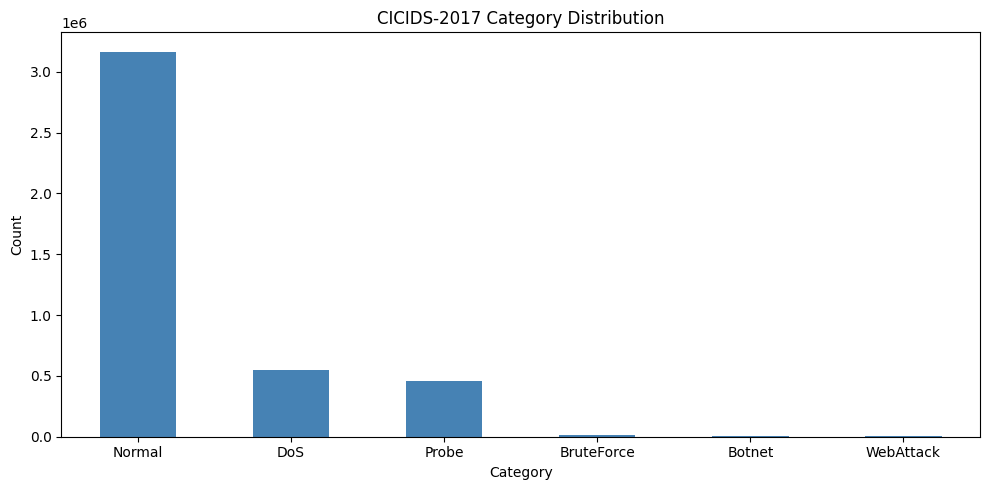


=== EDA Complete! ===
✅ Total records  : 4,199,942
✅ Total features : 84
✅ Categories     : Normal, DoS, Probe, BruteForce, WebAttack, Botnet
✅ Missing values : 0

Ready for preprocessing! 🚀


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-feature columns
drop_cols = ['Src IP dec', 'Dst IP dec', 'Timestamp', 'Label', 'Attempted Category', 'Category']
feature_cols = [c for c in full_df.columns if c not in drop_cols]

print(f"✅ Total features available: {len(feature_cols)}")
print(f"✅ Feature names sample: {feature_cols[:10]}")

# Plot category distribution
plt.figure(figsize=(10, 5))
full_df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('CICIDS-2017 Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== EDA Complete! ===")
print(f"✅ Total records  : {full_df.shape[0]:,}")
print(f"✅ Total features : {len(feature_cols)}")
print(f"✅ Categories     : Normal, DoS, Probe, BruteForce, WebAttack, Botnet")
print(f"✅ Missing values : 0")
print(f"\nReady for preprocessing! 🚀")